# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [5]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [21]:
print("So dong :", df.shape[0], "So cot :", df.shape[1])
df.info()


So dong : 1338 So cot : 7
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## A.2. Missing values & Duplicate data

In [25]:
print("So hang bi trống:", df.isnull().sum().sum())
print("So hang duplicate:", df.duplicated().sum())


So hang bi trống: 0
So hang duplicate: 1


## A.3. Invalid values

In [27]:
print("Invalid age:", (df['age'] <= 0).sum())
print("Invalid bmi:", (df['bmi'] <= 0).sum())
print("Invalid children:", (df['children'] < 0).sum())
print("Invalid sex:", (~df['sex'].isin(['male', 'female'])).sum())
print("Invalid smoker:", (~df['smoker'].isin(['yes', 'no'])).sum())
print("Invalid region:", (~df['region'].isin(
    ['southwest', 'southeast', 'northwest', 'northeast']
)).sum())
print("Invalid charges:", (df['charges'] <= 0).sum())

Invalid age: 0
Invalid bmi: 0
Invalid children: 0
Invalid sex: 0
Invalid smoker: 0
Invalid region: 0
Invalid charges: 0


## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [26]:
bmi_bins = [-np.inf, 25, 30, np.inf]
bmi_labels = ['Normal', 'Overweight', 'Obese']
df['bmi_group'] = pd.cut(df['bmi'], bins=bmi_bins, labels=bmi_labels, right=False)
df[['bmi', 'bmi_group']].head()

,bmi,bmi_group
0,27.900,Overweight
1,33.770,Obese
2,33.000,Obese
3,22.705,Normal
4,28.880,Overweight


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [28]:
for col in ['charges']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")
print()

charges: Mean=13270.42, Median=9382.03, Mode=1639.56



## Group 2 — Dispersion

In [29]:
for col in ['charges']:
    s = df[col]
    range_ = s.max()-s.min()
    std_ = s.std()
    q1,q3 = s.quantile([0.25,0.75]); iqr = q3-q1
    cv = std_/s.mean()
    print(f"--- {col} ---")
    print(f"Range={range_:.2f}, Std={std_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")


--- charges ---
Range=62648.55, Std=12110.01, IQR=11899.63, CV=0.91


## Group 3 — Location and Shape

--- charges ---
P25=4740.29, P50=9382.03, P75=16639.91
Skewness=1.51, Kurtosis=1.60


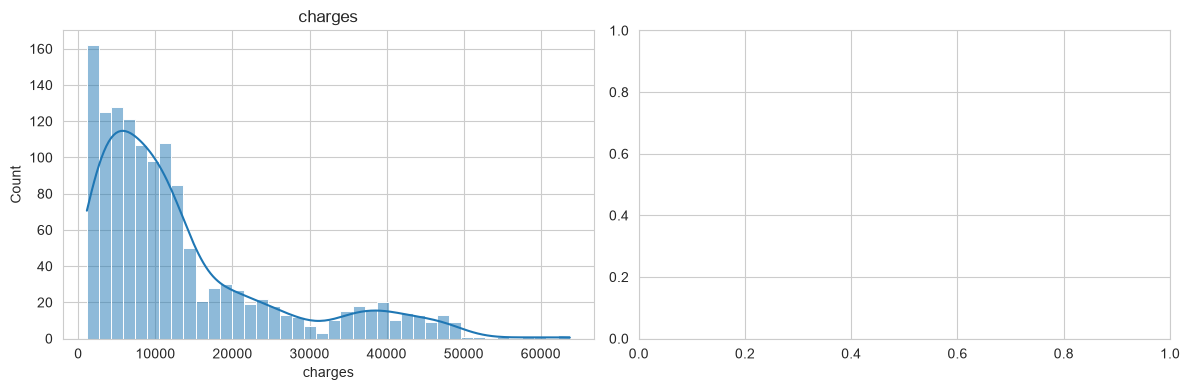

In [58]:
for col in ['charges']:
    s = df[col]
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['charges'],bins=40,kde=True,ax=axes[0]); axes[0].set_title('charges')


plt.tight_layout(); plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

In [ ]:
avg_smoker = df.groupby('smoker')['charges'].mean()
print("Chi phí trung bình:")
print(avg_smoker)
# Số lần người hút thuốc trả cao hơn
ratio = avg_smoker['yes'] / avg_smoker['no']
print("\nNgười hút thuốc trả cao hơn:", round(ratio, 2), "lần")
# So sánh theo từng vùng
region_smoker = df.groupby(['region', 'smoker'])['charges'].mean().unstack()
region_smoker['ratio'] = region_smoker['yes'] / region_smoker['no']
print("\nChi phí trung bình theo vùng:")
print(region_smoker)
print("Chi phí của người hút thuốc cao khoảng 3,8 lần, và mức chênh lệch có thay đổi tùy theo vùng.")

Chi phí trung bình:
smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

Người hút thuốc trả cao hơn: 3.8 lần

Chi phí trung bình theo vùng:
smoker              no           yes     ratio
region                                        
northeast  9165.531672  29673.536473  3.237514
northwest  8556.463715  30192.003182  3.528561
southeast  8032.216309  34844.996824  4.338155
southwest  8019.284513  32269.063494  4.023933
Chi phí của người hút thuốc cao khoảng 3,8 lần, và mức chênh lệch có thay đổi tùy theo vùng.


## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

In [52]:
smoker_corr = df[df['smoker'] == 'yes']['bmi'].corr(
    df[df['smoker'] == 'yes']['charges']
)

non_smoker_corr = df[df['smoker'] == 'no']['bmi'].corr(
    df[df['smoker'] == 'no']['charges']
)

print("Tương quan BMI - Charges ở người hút thuốc:", round(smoker_corr, 3))
print("Tương quan BMI - Charges ở người không hút thuốc:", round(non_smoker_corr, 3))

if abs(smoker_corr) > abs(non_smoker_corr):
    print("=> BMI tương quan mạnh hơn với charges ở nhóm hút thuốc.")
else:
    print("=> BMI tương quan mạnh hơn với charges ở nhóm không hút thuốc.")


Tương quan BMI - Charges ở người hút thuốc: 0.806
Tương quan BMI - Charges ở người không hút thuốc: 0.084
=> BMI tương quan mạnh hơn với charges ở nhóm hút thuốc.


## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

In [53]:
avg_charges_region = df.groupby('region')['charges'].mean().sort_values(ascending=False)

print(avg_charges_region)
print("Northeast là vùng có chi phí bảo hiểm trung bình cao nhất.")


region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64
Northeast là vùng có chi phí bảo hiểm trung bình cao nhất.


## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

In [55]:
avg_charges_children = df.groupby('children')['charges'].mean()

print(avg_charges_children)
print("Số lượng con cái có ảnh hưởng đến chi phí bảo hiểm, nhưng ảnh hưởng không mạnh và không tăng đều theo số con nên không thể kết luận rằng càng nhiều con thì chi phí bảo hiểm càng cao.")


children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64
Số lượng con cái có ảnh hưởng đến chi phí bảo hiểm, nhưng ảnh hưởng không mạnh và không tăng đều theo số con nên không thể kết luận rằng càng nhiều con thì chi phí bảo hiểm càng cao.


## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

In [57]:
r = df['age'].corr(df['charges'])
print("Hệ số tương quan r:", round(r, 3))
print("Tuổi có tương quan dương với chi phí bảo hiểm: người càng lớn tuổi thì charges có xu hướng tăng.")


Hệ số tương quan r: 0.299
Tuổi có tương quan dương với chi phí bảo hiểm: người càng lớn tuổi thì charges có xu hướng tăng.


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

Tình trạng hút thuốc là yếu tố có ảnh hưởng rõ rệt nhất đến chi phí bảo hiểm, khi người hút thuốc có chi phí trung bình cao hơn nhiều lần so với người không hút thuốc. BMI cũng có tương quan với chi phí bảo hiểm, trong đó mối tương quan mạnh hơn ở nhóm hút thuốc. Xét theo khu vực, vùng Northeast có chi phí bảo hiểm trung bình cao nhất, tuy nhiên sự khác biệt giữa các vùng không quá lớn so với ảnh hưởng của tình trạng hút thuốc. Số lượng con cái không cho thấy xu hướng làm chi phí bảo hiểm tăng đều, nên ảnh hưởng của yếu tố này khá yếu. Ngoài ra, tuổi có tương quan dương với chi phí, cho thấy người lớn tuổi thường có xu hướng phát sinh chi phí bảo hiểm cao hơn.